In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

/opt/py_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
# Custom loader function for .npy files
def npy_loader(path):
    """Load .npy file and convert to tensor"""
    image = np.load(path).astype(np.float32)
    
    image = torch.from_numpy(image)

    # Add channel dimension
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)
    
    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image

synth_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth"),
    extensions = (".npy"),
    loader = npy_loader
)
meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "alvin_edited_files/log_mapping/real"),
    extensions = (".npy"),
    loader = npy_loader
)

In [4]:
def extract_elev(path):
    match = re.search(r"elevDeg_(\d{3})", path)
    if match:
        return int(match.group(1))
    return None

def filter_by_elev(dataset, allowed_angles):
    filtered = []
    ds_cp = copy.deepcopy(dataset)
    for path, label in dataset.samples:
        elev = extract_elev(path)
        if elev in allowed_angles:
            filtered.append((path, label))
    ds_cp.samples = filtered
    ds_cp.targets = [label for _, label in filtered]
    return ds_cp

In [5]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

## Batch 32

In [6]:
ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

dataloaders = {x : DataLoader(ds_dict[x], batch_size = 32, num_workers = 4, shuffle = True) for x in ds_dict.keys()}

In [7]:
for i in range(10):
    print(f"Training Run {i}")
    # load pre-trained model
    model = models.resnet18(weights = "DEFAULT")

    # Replace final layer for the number of classes
    model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.Adam(model.parameters(), lr = 10**(-3))
    
    scheduler = CosineAnnealingLR(optimizer, T_max=100)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "train_acc": []
    }
    
    # Training loops
    num_epochs = 100
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())
    
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32_epoch0.pth"))
        
    print("Training complete!")

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32.pth"))

Training Run 0
Epoch 0
train Loss: 0.7917 Acc: 0.7320
Epoch 0 LR: 0.0009997533
Epoch 1
train Loss: 0.0884 Acc: 0.9739
Epoch 1 LR: 0.0009990134
Epoch 2
train Loss: 0.0443 Acc: 0.9876
Epoch 2 LR: 0.0009977810
Epoch 3
train Loss: 0.0681 Acc: 0.9851
Epoch 3 LR: 0.0009960574
Epoch 4
train Loss: 0.0153 Acc: 0.9938
Epoch 4 LR: 0.0009938442
Epoch 5
train Loss: 0.0671 Acc: 0.9727
Epoch 5 LR: 0.0009911436
Epoch 6
train Loss: 0.0805 Acc: 0.9727
Epoch 6 LR: 0.0009879584
Epoch 7
train Loss: 0.0437 Acc: 0.9864
Epoch 7 LR: 0.0009842916
Epoch 8
train Loss: 0.0121 Acc: 0.9950
Epoch 8 LR: 0.0009801468
Epoch 9
train Loss: 0.0084 Acc: 0.9988
Epoch 9 LR: 0.0009755283
Epoch 10
train Loss: 0.0143 Acc: 0.9950
Epoch 10 LR: 0.0009704404
Epoch 11
train Loss: 0.0295 Acc: 0.9913
Epoch 11 LR: 0.0009648882
Epoch 12
train Loss: 0.0865 Acc: 0.9764
Epoch 12 LR: 0.0009588773
Epoch 13
train Loss: 0.0527 Acc: 0.9826
Epoch 13 LR: 0.0009524135
Epoch 14
train Loss: 0.0215 Acc: 0.9938
Epoch 14 LR: 0.0009455033
Epoch 15
train 

In [24]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.2282
Evaluating Run 1
Test Accuracy: 0.2208
Evaluating Run 2
Test Accuracy: 0.1800
Evaluating Run 3
Test Accuracy: 0.1725
Evaluating Run 4
Test Accuracy: 0.1132
Evaluating Run 5
Test Accuracy: 0.2560
Evaluating Run 6
Test Accuracy: 0.2393
Evaluating Run 7
Test Accuracy: 0.1039
Evaluating Run 8
Test Accuracy: 0.2542
Evaluating Run 9
Test Accuracy: 0.2690


In [8]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.6419
Evaluating Run 1
Test Accuracy: 0.5399
Evaluating Run 2
Test Accuracy: 0.6716
Evaluating Run 3
Test Accuracy: 0.6289
Evaluating Run 4
Test Accuracy: 0.4972
Evaluating Run 5
Test Accuracy: 0.6271
Evaluating Run 6
Test Accuracy: 0.7273
Evaluating Run 7
Test Accuracy: 0.6401
Evaluating Run 8
Test Accuracy: 0.8182
Evaluating Run 9
Test Accuracy: 0.6568


In [9]:
np.array(test_acc_lst).mean() * 100, np.array(test_acc_lst).std() * 100

(np.float64(64.48979591836735), np.float64(8.432562639349573))

## Batch 64

In [5]:
ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

dataloaders = {x : DataLoader(ds_dict[x], batch_size = 64, num_workers = 4, shuffle = True) for x in ds_dict.keys()}

In [6]:
for i in range(10):
    print(f"Training Run {i}")
    # load pre-trained model
    model = models.resnet18(weights = "DEFAULT")

    # Replace final layer for the number of classes
    model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.Adam(model.parameters(), lr = 10**(-3))
    
    scheduler = CosineAnnealingLR(optimizer, T_max=100)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "train_acc": []
    }
    
    # Training loops
    num_epochs = 100
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())
    
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), f"/workspace/alvin/SAR_ML/weights/SSR/wo_aug/rn18_run{i}_b64_epoch0.pth")
        
    print("Training complete!")

    torch.save(model.state_dict(), f"/workspace/alvin/SAR_ML/weights/SSR/wo_aug/rn18_run{i}_b64.pth")

Training Run 0
Epoch 0
train Loss: 1.0004 Acc: 0.6712
Epoch 0 LR: 0.0009997533
Epoch 1
train Loss: 0.0810 Acc: 0.9801
Epoch 1 LR: 0.0009990134
Epoch 2
train Loss: 0.0135 Acc: 0.9963
Epoch 2 LR: 0.0009977810
Epoch 3
train Loss: 0.0040 Acc: 1.0000
Epoch 3 LR: 0.0009960574
Epoch 4
train Loss: 0.0013 Acc: 1.0000
Epoch 4 LR: 0.0009938442
Epoch 5
train Loss: 0.0006 Acc: 1.0000
Epoch 5 LR: 0.0009911436
Epoch 6
train Loss: 0.0005 Acc: 1.0000
Epoch 6 LR: 0.0009879584
Epoch 7
train Loss: 0.0002 Acc: 1.0000
Epoch 7 LR: 0.0009842916
Epoch 8
train Loss: 0.0003 Acc: 1.0000
Epoch 8 LR: 0.0009801468
Epoch 9
train Loss: 0.0003 Acc: 1.0000
Epoch 9 LR: 0.0009755283
Epoch 10
train Loss: 0.0002 Acc: 1.0000
Epoch 10 LR: 0.0009704404
Epoch 11
train Loss: 0.0002 Acc: 1.0000
Epoch 11 LR: 0.0009648882
Epoch 12
train Loss: 0.0002 Acc: 1.0000
Epoch 12 LR: 0.0009588773
Epoch 13
train Loss: 0.0003 Acc: 1.0000
Epoch 13 LR: 0.0009524135
Epoch 14
train Loss: 0.0001 Acc: 1.0000
Epoch 14 LR: 0.0009455033
Epoch 15
train 

In [7]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        f"/workspace/alvin/SAR_ML/weights/SSR/wo_aug/rn18_run{i}_b64.pth",
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.5176
Evaluating Run 1
Test Accuracy: 0.4972
Evaluating Run 2
Test Accuracy: 0.4100
Evaluating Run 3
Test Accuracy: 0.5343
Evaluating Run 4
Test Accuracy: 0.6308
Evaluating Run 5
Test Accuracy: 0.6994
Evaluating Run 6
Test Accuracy: 0.8163
Evaluating Run 7
Test Accuracy: 0.5677
Evaluating Run 8
Test Accuracy: 0.5455
Evaluating Run 9
Test Accuracy: 0.5659


In [8]:
np.array(test_acc_lst).mean() * 100, np.array(test_acc_lst).std() * 100

(np.float64(57.84786641929498), np.float64(10.76763896774328))

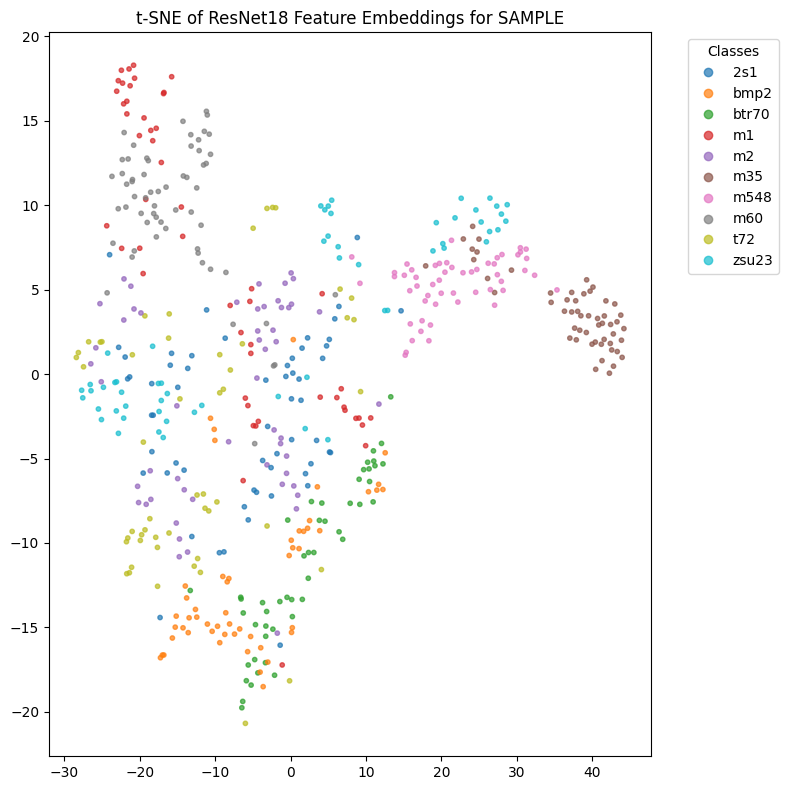

In [18]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

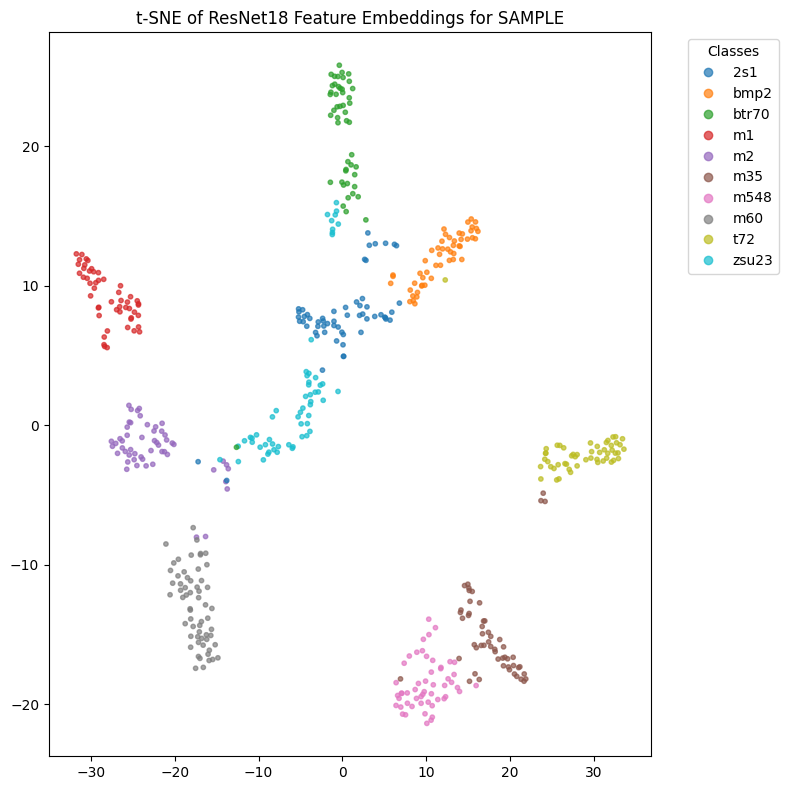

In [19]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

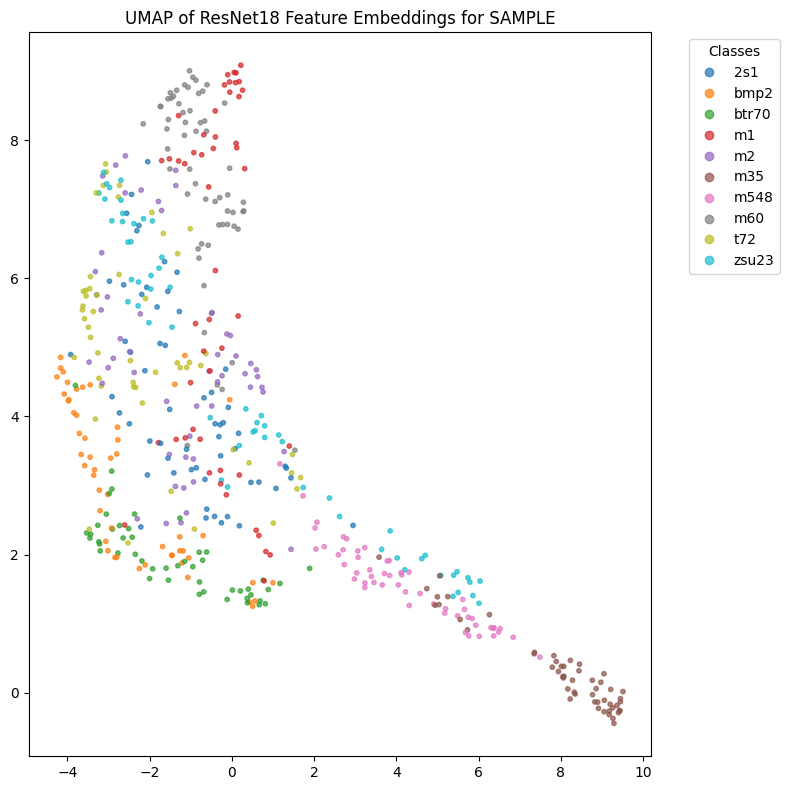

In [21]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

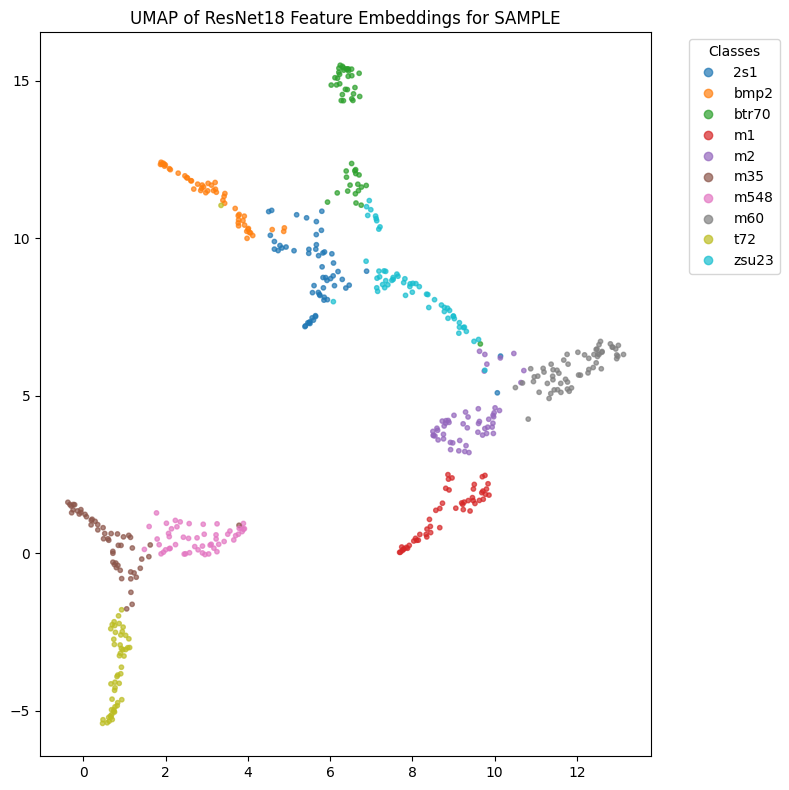

In [22]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [23]:
train_ds.class_to_idx

{'2s1': 0,
 'bmp2': 1,
 'btr70': 2,
 'm1': 3,
 'm2': 4,
 'm35': 5,
 'm548': 6,
 'm60': 7,
 't72': 8,
 'zsu23': 9}